In [12]:
import Bounded_Saddle_Yolo

import os
import sys

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

import math
import pickle
from tqdm.auto import tqdm

import importlib
importlib.reload(Bounded_Saddle_Yolo);

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
BE = Bounded_Saddle_Yolo.BoardExtractor()
# Bounded_Saddle_Yolo.bd.model.to("cpu")
def preprocess_fn(padding=(0,0)):
    def main(img):
        BE.set_img(img)
        quad, conf = BE.extract_board()
        warpped, M = BE.warp(quad, padding)
        
        return warpped

    return main

def post_transform(img):
    return torch.tensor(img).permute(2,0,1)

class ChessDataset(Dataset):
    def __init__(self, root_dir, labels_path, img_transforms=None, padding=(0,0)):
        super().__init__()

        self.labels = []

        self.transforms = transforms.Compose([
            transforms.ToTensor(),
            preprocess_fn(padding),
            post_transform,
        ])
        self.post_transforms = img_transforms

        with open(labels_path, "rb") as f:
            data = pickle.load(f)
        
        for item in data:
            if "file_path" not in item:
                continue

            path = item["file_path"]
            img_path = os.path.join(root_dir, path)
            if not os.path.exists(img_path):
                continue

            item["file_path"] = img_path

            self.labels.append(item)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        try:
            label = self.labels[index]
            img_path = label["file_path"]

            img = Image.open(img_path).convert("RGB").resize((640,640))

            img = self.transforms(img)

            if self.post_transforms is not None:
                img = self.post_transforms(img)

            return img, label
        except Exception as e:
            print(index, self.labels[index]["file_path"])
            print(e)
            raise e
    
    def getLoader(self, batch_size=32):
        # return DataLoader(self, batch_size=32, shuffle=True, pin_memory=True, num_workers=4, prefetch_factor=2, persistent_workers=True)
        return DataLoader(self, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=0)

In [4]:
ds = ChessDataset("../data/data_manual/full_dataset/manual_dataset", "../data/data_manual/full_dataset/annotations_manual_2.pkl", padding=(32,32))
dl = ds.getLoader(8)

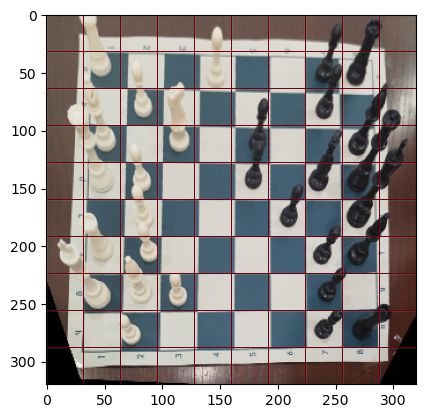

In [5]:
warpped, y = ds[0]

grid = np.zeros((warpped.shape[1], warpped.shape[2]))
step = 32
# Set pixels in rows and columns that are multiples of step to 1
grid[::step, :] = 1   # horizontal lines
grid[:, ::step] = 1   # vertical lines

plt.imshow(warpped.permute(1,2,0));
plt.imshow(grid, alpha=grid, cmap='Reds');

In [22]:
class PieceDetectorCNN(nn.Module):
    def __init__(self):
        super().__init__()

        dropporb = .2

        self.conv1 = nn.Sequential(
            # 32, 32
            nn.Conv2d(3, 16, 3, padding=1),
            nn.LeakyReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(4),
            nn.Dropout(dropporb),

            # 8, 8
            nn.Conv2d(16, 64, 3, padding=1),
            nn.LeakyReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(4),
            nn.Dropout(dropporb),

            # 2,2
            nn.Conv2d(64, 128, 3, padding=1),
            nn.LeakyReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(dropporb),

            # 1, 1
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(),
            # nn.BatchNorm2d(128),
            nn.Dropout(dropporb),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(),
            # nn.BatchNorm2d(128),
            nn.Dropout(dropporb),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Dropout(dropporb),

            nn.Linear(64, 13)
        )

        self.pos_emb = nn.Parameter(torch.zeros(128, 10, 10))
        self.sin_pos_emb = None  # [C, 10, 10]

    def sinusoidal_embeddings_2d(self, height=10, width=10, d_model=128):
        """
        Create 2D sinusoidal positional embeddings for an (H, W) grid.

        height, width: grid size
        d_model: total embedding dimension (should be even)

        Returns:
            pos_emb: [H, W, d_model] tensor
        """
        if self.sin_pos_emb is not None and (tuple(self.sin_pos_emb.shape) == (d_model, height, width)):
            return self.sin_pos_emb

        if d_model % 4 != 0:
            raise ValueError("d_model must be divisible by 4 for 2D sin/cos.")

        # Position indices
        y_pos = torch.arange(height, dtype=torch.float32).unsqueeze(1)  # [H, 1]
        x_pos = torch.arange(width, dtype=torch.float32).unsqueeze(1)   # [W, 1]

        # Each axis gets d_model/2 dimensions, split into sin/cos → d_model/4 each
        d_model_half = d_model // 2
        div_term = torch.exp(torch.arange(0, d_model_half, 2).float() * (-math.log(10000.0) / d_model_half))

        # Row (y) embeddings
        pe_y = torch.zeros(height, d_model_half)
        pe_y[:, 0::2] = torch.sin(y_pos * div_term)
        pe_y[:, 1::2] = torch.cos(y_pos * div_term)

        # Col (x) embeddings
        pe_x = torch.zeros(width, d_model_half)
        pe_x[:, 0::2] = torch.sin(x_pos * div_term)
        pe_x[:, 1::2] = torch.cos(x_pos * div_term)

        # Combine row and col into [H, W, d_model]
        pe = torch.zeros(height, width, d_model)
        for i in range(height):
            for j in range(width):
                pe[i, j] = torch.cat([pe_y[i], pe_x[j]], dim=0)

        self.sin_pos_emb = pe.permute(2, 0, 1).to(device)
        return self.sin_pos_emb

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        sq_size = (x.shape[2]//10, x.shape[3]//10)
        B = x.shape[0]
        C = x.shape[1]
        if C != 3:
            raise Exception("Invalid Image")
        
        board_split = x.reshape(B, C, 10, sq_size[0], 10, sq_size[1]).permute(0,1,2,4,3,5)

        embeds = self.conv1(board_split.permute(0,2,3,1,4,5).reshape(-1,C,sq_size[0],sq_size[1])).squeeze(-1).squeeze(-1).reshape(B, 10,10, 128).permute(0,3,1,2)

        sin_pos_emb = self.sinusoidal_embeddings_2d(10,10, 128)

        positioned_embeds = embeds + self.pos_emb + sin_pos_emb
        # attentioned_embeds = embeds.reshape(B, 10,10, 128).permute(0,3,1,2)
        attentioned_embeds = self.conv2(positioned_embeds)
        cropped_attentioned_embeds = attentioned_embeds[:,:,1:9,1:9]
        res = self.classifier(cropped_attentioned_embeds.permute(0,2,3,1).reshape(-1, 128)).reshape(B, 8,8, 13)

        return res

In [23]:
model = PieceDetectorCNN().to(device)

(32, 32) torch.Size([8, 3, 320, 320])
torch.Size([8, 8, 8, 13])
{'image_id': tensor([45, 24, 44, 64, 35, 39, 47, 21]), 'file_path': ['../data/data_manual/full_dataset/manual_dataset/images/img45.jpg', '../data/data_manual/full_dataset/manual_dataset/images/img24.jpg', '../data/data_manual/full_dataset/manual_dataset/images/img44.jpg', '../data/data_manual/full_dataset/manual_dataset/images/img64.jpg', '../data/data_manual/full_dataset/manual_dataset/images/img35.jpg', '../data/data_manual/full_dataset/manual_dataset/images/img39.jpg', '../data/data_manual/full_dataset/manual_dataset/images/img47.jpg', '../data/data_manual/full_dataset/manual_dataset/images/img21.jpg'], 'fen': ['7r/p4p2/1ppPp3/2n3Pp/7R/4K3/P4P2/7R b - - 1 29', 'r3rbk1/1p5p/pn1p4/2pP1pBn/4N3/1P3B2/1P2PP1P/R3R1K1 w - - 0 21', '5b2/7p/p3kp2/1p2pN2/2r2pP1/2PK1P2/P1P4P/1R6 w - - 11 33', '4rrk1/pp3p1p/6p1/3Q4/4P3/2P2q2/P4P1P/3RR2K w - - 14 29', '1r6/2p1q1kp/p5p1/Pr1nn3/4Pp2/RpP3QP/1P1N1PP1/R2B2K1 b - - 1 26', '8/1p3p2/p7/8/1P

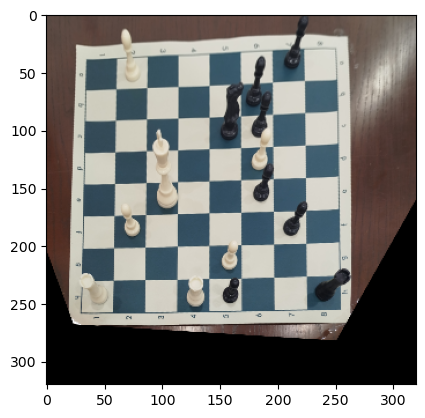

In [28]:
for x, l in dl:
    res = model(x.to(device))
    print(res.shape)
    print(l)

    plt.imshow(x[0].permute(1,2,0));
    break

In [24]:
def train(model: nn.Module, train_loader, lr=1e-3, epochs=30):
    optimzier = torch.optim.Adam(model.parameters(), lr=lr)
    class_weights = 64/(torch.tensor([8,2,2,2,1,1,8,2,2,2,1,1,32]))
    loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))

    for epoch in range(epochs):
        train_loss = 0
        train_acc = 0
        train_count = 0
        for X, L in tqdm(train_loader):
            y = L["y"]
            X = X.to(device)
            y = y.to(device)

            preds: torch.Tensor = model(X).reshape(-1, 13)
            y = y.reshape(-1, 13).argmax(dim=1)

            optimzier.zero_grad()
            loss: torch.Tensor = loss_fn(preds, y)
            loss.backward()
            optimzier.step()

            train_loss += loss.item()
            train_count += X.shape[0]*8*8

            train_acc += (preds.softmax(dim=1).argmax(dim=1) == y).sum().item()

        train_loss /= train_count
        train_acc /= train_count

        print(f"Epoch {epoch+1}/{epochs} |  Loss {train_loss:.4f} | Accuracy {train_acc:.2f}")

In [27]:
train(model, dl, epochs=10)

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 1/10 |  Loss 0.0012 | Accuracy 0.89


  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 2/10 |  Loss 0.0010 | Accuracy 0.91


  0%|          | 0/12 [00:00<?, ?it/s]

...

Epoch 8/10 |  Loss 0.0007 | Accuracy 0.92


  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 9/10 |  Loss 0.0006 | Accuracy 0.93


  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 10/10 |  Loss 0.0005 | Accuracy 0.94


In [28]:
torch.save(model.state_dict(), "best_model.pt")

In [31]:
import sys
sys.path.append("../Utils")
import ChessUtils

In [32]:
f = ds[0][1]["fen"]
ChessUtils.ChessTensorUtils().FENtoTensor(f).permute(0,2,3,1)[0,0,0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [33]:
cu = ChessUtils.ChessTensorUtils()

In [ ]:
cu = ChessUtils.ChessTensorUtils()
with open("../data/data_manual/full_dataset/annotations_manual.pkl", "rb") as f:
    x = pickle.load(f)

for i in range(len(x)):
    x[i]["y"] = cu.FENtoTensor(x[i]["fen"]).permute(0,2,3,1).squeeze().rot90(-1, (0,1))

with open("../data/data_manual/full_dataset/annotations_manual_2.pkl", "wb") as f:
    pickle.dump(x, f)

(tensor([[ 3, 12, 12,  0, 12, 12,  6,  9],
         [12,  0, 12, 12, 12, 12,  6, 12],
         [ 2, 12,  1, 12,  6, 12, 12,  8],
         [ 4,  0, 12, 12,  6, 12,  7, 10],
         [12,  0, 12, 12, 12,  6, 12, 11],
         [ 3,  0, 12, 12, 12, 12,  6,  8],
         [ 5,  2,  0, 12, 12, 12,  6, 12],
         [12,  0, 12, 12, 12, 12,  6,  9]]),
 '../data/data_manual/full_dataset/manual_dataset/images/img1.jpg',
 tensor(2))

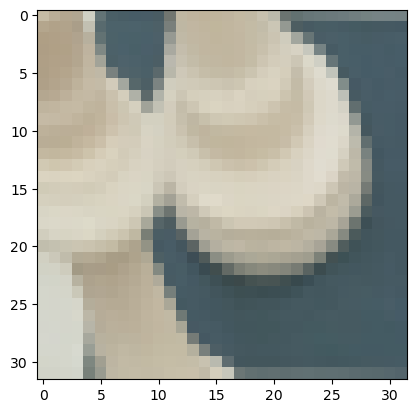

In [20]:
x, y = ds[0]

x = x.unsqueeze(0)

sq_size = (x.shape[2]//10, x.shape[3]//10)
B = x.shape[0]
C = x.shape[1]
if C != 3:
    raise Exception("Invalid Image")

board_split = x.reshape(B, C, 10, sq_size[0], 10, sq_size[1]).permute(0,1,2,4,3,5)

plt.imshow(board_split[0,:,3,1,:,:].permute(1,2,0));

y['y'].argmax(dim=2), y['file_path'], y['y'].argmax(dim=2)[2,0]

In [34]:
with torch.inference_mode():
    x = ds[0][0].unsqueeze(0).to(device)
    preds = model(x)
preds.shape

torch.Size([1, 8, 8, 13])

In [35]:
board = preds.squeeze().argmax(2).rot90(1).unsqueeze(0)
print(board.shape)
cu.tensorToFEN_MAX(board)

torch.Size([1, 8, 8])


'r1bqkb1r/pp1n1ppp/4p3/2pp4/P7/2B3P1/1P1NP1BP/R1BQ1RK1'

In [36]:
img = Image.open("../data/data_old/9.jpeg").convert("RGB").resize((640,640))
img = ds.transforms(img)

with torch.inference_mode():
    x = img.unsqueeze(0).to(device)
    preds = model(x)

board = preds.squeeze().argmax(2).rot90(1).unsqueeze(0)
cu.tensorToFEN_MAX(board)

'3r1r1r/pp2kQpp/2ppn3/1pP1n1P1/7P/3QP3/P4R2/RQ2R2R'